# Passenger Demand Analysis Notebook

This notebook contains independent visual analyses built from the processed CSV files.

Each visualization is organized as:
- **1** for the first visualization and its subsections
- **2** for the second visualization and its subsections
- and so on

Each section is self-contained, including its own imports, parameters, processing logic, plotting steps, and memory cleanup.

# 1. Passenger Peak Analysis

## 1.1 Objective

The goal of this visualization is to identify passenger demand peaks throughout the day.

More specifically, this analysis aggregates all transactions across all CSV files and counts how many passenger records occur in each hour of the day.

Each row in the dataset is treated as one passenger transaction.

## 1.2 Expected Output

This section produces a chart showing:

- **x-axis:** hour of day (0 to 23)
- **y-axis:** total number of passengers
- **scope:** all CSV files found recursively inside the selected directory

## 1.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

## Dataset Overview 

In [46]:
import os
import pandas as pd
from pathlib import Path

def explore_csv_folder(folder_path, max_rows=5):
    """
    Open all CSV files in a folder, concatenate them into a single DataFrame,
    and display head and column descriptions.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing CSV files
    max_rows : int
        Number of rows to display in head (default: 5)
    
    Returns:
    --------
    pandas.DataFrame
        Consolidated DataFrame containing all CSV data appended together
    """
    csv_files = list(Path(folder_path).glob('*.csv'))
    
    if not csv_files:
        print(f"No CSV files found in {folder_path}")
        return None
    
    # List to accumulate DataFrames
    dfs = []
    
    for csv_file in sorted(csv_files):
        print(f"\n📄 FILE: {csv_file.name}")
        
        try:
            df = pd.read_csv(csv_file)
            dfs.append(df)
            print(f"   ✓ Loaded {len(df)} rows")
        except Exception as e:
            print(f"   ❌ Error reading {csv_file.name}: {e}")
    
    if not dfs:
        print("No CSV files were successfully loaded.")
        return None
    
    # Concatenate all DataFrames
    consolidated_df = pd.concat(dfs, ignore_index=True)
    
    # Display consolidated information
    print(f"\n{'='*80}")
    print(f"📊 CONSOLIDATED DATA")
    print(f"{'='*80}")
    print(f"Total files processed: {len(dfs)}")
    print(f"Consolidated shape: {consolidated_df.shape[0]} rows × {consolidated_df.shape[1]} columns\n")
    
    # Display head
    print(f"🔝 HEAD ({min(max_rows, len(consolidated_df))} rows):")
    print(consolidated_df.head(max_rows).to_string())
    
    # Display column descriptions
    print(f"\n📊 COLUMN DESCRIPTIONS:")
    print(consolidated_df.info())
    
    print(f"\n📈 SUMMARY STATISTICS:")
    print(consolidated_df.describe().to_string())
    
    return consolidated_df

In [47]:
df_data = explore_csv_folder('/data/vm/anonymyzed_seq/', max_rows=31)


📄 FILE: 2026-03-01.csv
   ✓ Loaded 68477 rows

📄 FILE: 2026-03-02.csv
   ✓ Loaded 275388 rows

📄 FILE: 2026-03-03.csv
   ✓ Loaded 285710 rows

📄 FILE: 2026-03-04.csv
   ✓ Loaded 283604 rows

📄 FILE: 2026-03-05.csv
   ✓ Loaded 287334 rows

📄 FILE: 2026-03-06.csv
   ✓ Loaded 283920 rows

📄 FILE: 2026-03-07.csv
   ✓ Loaded 142297 rows

📄 FILE: 2026-03-08.csv
   ✓ Loaded 76849 rows

📄 FILE: 2026-03-09.csv
   ✓ Loaded 259158 rows

📄 FILE: 2026-03-10.csv


   ✓ Loaded 292513 rows

📄 FILE: 2026-03-11.csv
   ✓ Loaded 284898 rows

📄 FILE: 2026-03-12.csv
   ✓ Loaded 288589 rows

📄 FILE: 2026-03-13.csv
   ✓ Loaded 279948 rows

📄 FILE: 2026-03-14.csv
   ✓ Loaded 133743 rows

📄 FILE: 2026-03-15.csv
   ✓ Loaded 73999 rows

📄 FILE: 2026-03-16.csv
   ✓ Loaded 289306 rows

📄 FILE: 2026-03-17.csv
   ✓ Loaded 297946 rows

📄 FILE: 2026-03-18.csv
   ✓ Loaded 295244 rows

📄 FILE: 2026-03-19.csv
   ✓ Loaded 296725 rows

📄 FILE: 2026-03-20.csv
   ✓ Loaded 277539 rows

📄 FILE: 2026-03-21.csv
   ✓ Loaded 134725 rows

📄 FILE: 2026-03-22.csv
   ✓ Loaded 75632 rows

📄 FILE: 2026-03-23.csv
   ✓ Loaded 282890 rows

📄 FILE: 2026-03-24.csv
   ✓ Loaded 298750 rows

📄 FILE: 2026-03-25.csv
   ✓ Loaded 294524 rows

📄 FILE: 2026-03-26.csv
   ✓ Loaded 298181 rows

📄 FILE: 2026-03-27.csv
   ✓ Loaded 286824 rows

📄 FILE: 2026-03-28.csv
   ✓ Loaded 140601 rows

📄 FILE: 2026-03-29.csv
   ✓ Loaded 78323 rows

📄 FILE: 2026-03-30.csv
   ✓ Loaded 289477 rows

📄 FILE: 2026-03-31

In [48]:
df_data.tail()

,transaction_date,fare_type,vehicle_number,company_number,route_detail_id,integration_flag,card_type,debited_amount,view_type,route_name,day_type,day_period,anon_user_id
7247955,2026-03-31 23:56:01-03:00,3,2038,56,2714,1,-1,5.6,RIO DO OURO - CENTRO,48,1,1,0
7247956,2026-03-31 23:56:02-03:00,3,2034,56,2713,1,-1,5.6,VÁRZEA DAS MOÇAS - CENTRO,46,1,1,0
7247957,2026-03-31 23:59:32-03:00,3,2142,56,2723,1,-1,5.6,ITAIPU X CENTRO - (VIA PRAIA ICARAÍ),OC3,1,1,0
7247958,2026-03-31 23:59:45-03:00,1,22080,56,2727,1,4,0.0,ITITIOCA - CENTRO,44,1,1,339744
7247959,2026-03-31 23:59:57-03:00,1,2037,56,2713,1,3,0.0,VÁRZEA DAS MOÇAS - CENTRO,46,1,1,285380


In [49]:
# Display column names and general info
print("Columns:", df_data.columns.tolist())
df_data.info()

Columns: ['transaction_date', 'fare_type', 'vehicle_number', 'company_number', 'route_detail_id', 'integration_flag', 'card_type', 'debited_amount', 'view_type', 'route_name', 'day_type', 'day_period', 'anon_user_id']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7247960 entries, 0 to 7247959
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   transaction_date  object 
 1   fare_type         int64  
 2   vehicle_number    int64  
 3   company_number    int64  
 4   route_detail_id   int64  
 5   integration_flag  int64  
 6   card_type         int64  
 7   debited_amount    float64
 8   view_type         object 
 9   route_name        object 
 10  day_type          int64  
 11  day_period        int64  
 12  anon_user_id      int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 718.9+ MB


In [50]:
# 1.4 Code - Passenger demand by hour

def plot_passenger_demand_by_hour(data_dir):
    """
    Read all CSV files recursively from a directory, aggregate passenger records by hour,
    and plot the total number of passengers for each hour of the day.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - hour
        - passenger_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an accumulator with one slot for each hour of the day.
    hourly_counts = pd.Series(0, index=range(24), dtype="int64")

    # Process each CSV file individually to avoid loading everything into memory at once.
    for file_path in csv_files:
        # Read only the timestamp column required for this analysis.
        df = pd.read_csv(file_path, usecols=["transaction_date"])

        # Convert the timestamp column to datetime.
        # Invalid values are converted to NaT instead of raising an error.
        df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

        # Remove rows where the timestamp could not be parsed.
        df = df.dropna(subset=["transaction_date"])

        # Count how many transactions happened in each hour in this file.
        file_hourly_counts = df["transaction_date"].dt.hour.value_counts().sort_index()

        # Add the file counts to the global accumulator.
        hourly_counts = hourly_counts.add(file_hourly_counts, fill_value=0)

        # Delete temporary DataFrame to free memory before the next iteration.
        del df, file_hourly_counts
        gc.collect()

    # Convert final result to integer type and sort by hour.
    hourly_counts = hourly_counts.astype(int).sort_index()

    # Build a DataFrame for easier display and reuse.
    hourly_summary = pd.DataFrame({
        "hour": hourly_counts.index,
        "passenger_count": hourly_counts.values
    })

    # Plot the result.
    plt.figure(figsize=(12, 6))
    plt.plot(hourly_summary["hour"], hourly_summary["passenger_count"], marker="o")
    plt.title("Passenger Demand by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Passengers")
    plt.xticks(range(24))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return hourly_summary

## 1.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with hourly passenger totals
- a chart showing passenger demand by hour

Found 31 CSV files.


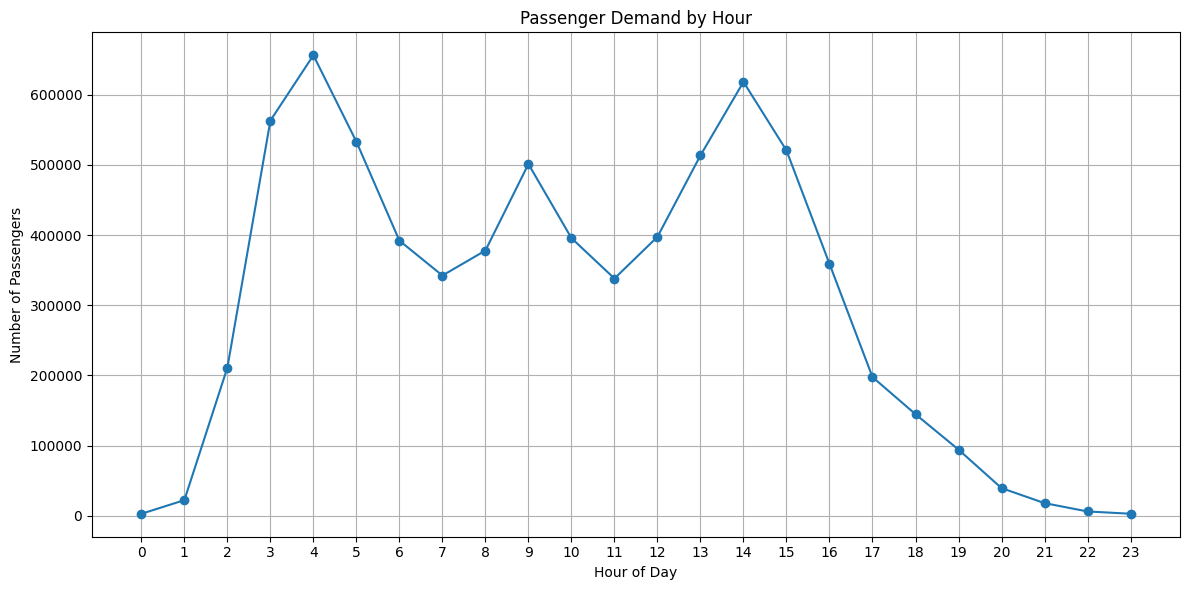

,hour,passenger_count
0,0,2787
1,1,22236
2,2,211094
3,3,563148
4,4,656270
5,5,533082
6,6,392067
7,7,342367
8,8,377983
9,9,501257


5793

In [51]:
# 1.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"

hourly_summary_1 = plot_passenger_demand_by_hour(DATA_DIR)
display(hourly_summary_1)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
gc.collect()

## 1.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [52]:
# 1.8 Cleanup

import gc

del hourly_summary_1
del plot_passenger_demand_by_hour
gc.collect()

0

# 2. Passengers by Day

## 2.1 Objective

The goal of this visualization is to measure daily passenger volume.

This analysis aggregates all transactions across all CSV files and counts how many passenger records occurred on each calendar day.

Each row in the dataset is treated as one passenger transaction.

## 2.2 Expected Output

This section produces a chart showing:

- **x-axis:** calendar date
- **y-axis:** total number of passengers
- **scope:** all CSV files found recursively inside the selected directory

## 2.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [53]:
# 2.4 Code - Passenger demand by day

def plot_passenger_demand_by_day(data_dir):
    """
    Read all CSV files recursively from a directory, aggregate passenger records by day,
    and plot the total number of passengers for each date.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - date
        - passenger_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty dictionary-like accumulator using pandas Series.
    daily_counts = pd.Series(dtype="int64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the timestamp column required for this analysis.
        df = pd.read_csv(file_path, usecols=["transaction_date"])

        # Convert the timestamp column to datetime.
        # Invalid values are converted to NaT.
        df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

        # Remove rows where the timestamp could not be parsed.
        df = df.dropna(subset=["transaction_date"])

        # Extract only the calendar date from each timestamp.
        df["date"] = df["transaction_date"].dt.date

        # Count passengers by date in the current file.
        file_daily_counts = df["date"].value_counts().sort_index()

        # Accumulate counts across all files.
        daily_counts = daily_counts.add(file_daily_counts, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_daily_counts
        gc.collect()

    # Convert final result to integer type and sort by date.
    daily_counts = daily_counts.astype(int).sort_index()

    # Build a DataFrame for easier display and reuse.
    daily_summary = pd.DataFrame({
        "date": daily_counts.index,
        "passenger_count": daily_counts.values
    })

    # Convert the date column back to pandas datetime for plotting.
    daily_summary["date"] = pd.to_datetime(daily_summary["date"])

    # Plot the result.
    plt.figure(figsize=(14, 6))
    plt.scatter(daily_summary["date"], daily_summary["passenger_count"], marker="o")
    plt.title("Passenger Demand by Day")
    plt.xlabel("Date")
    plt.ylabel("Number of Passengers")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return daily_summary

## 2.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with daily passenger totals
- a chart showing passenger demand by day

Found 31 CSV files.


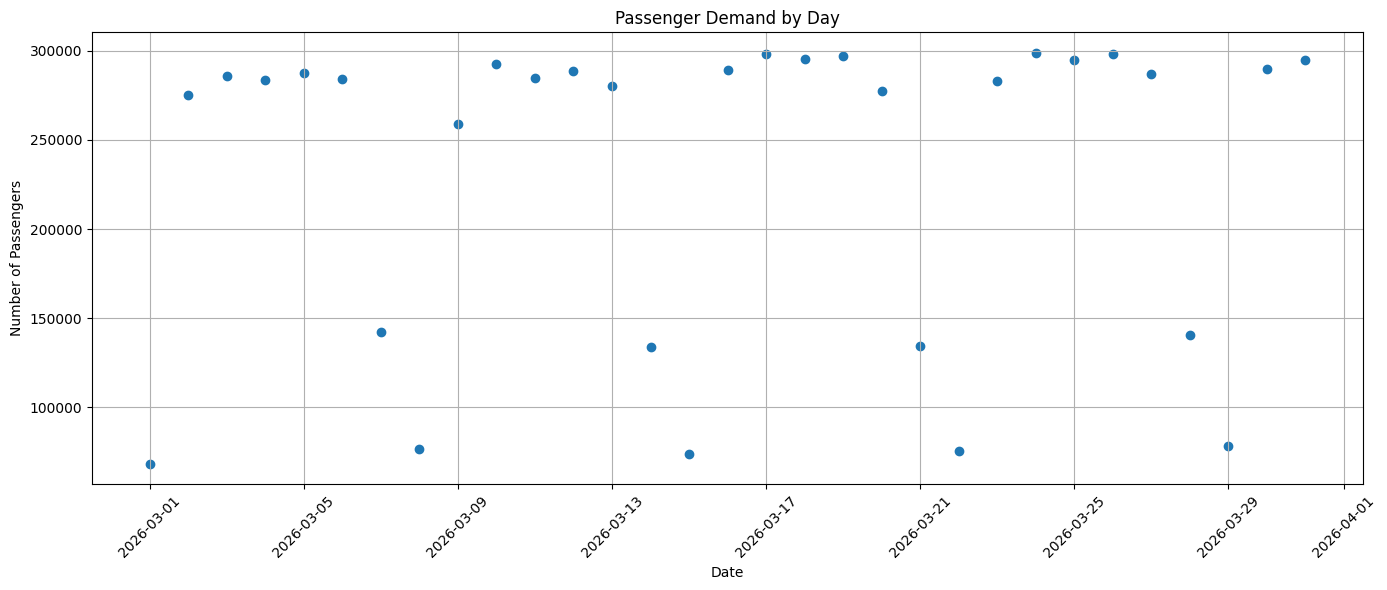

,date,passenger_count
0,2026-03-01,68477
1,2026-03-02,275388
2,2026-03-03,285710
3,2026-03-04,283604
4,2026-03-05,287334
5,2026-03-06,283920
6,2026-03-07,142297
7,2026-03-08,76849
8,2026-03-09,259158
9,2026-03-10,292513


3721

In [54]:
# 2.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"

daily_summary_2 = plot_passenger_demand_by_day(DATA_DIR)
display(daily_summary_2)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
gc.collect()

## 2.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [55]:
# 2.8 Cleanup

import gc

del daily_summary_2
del plot_passenger_demand_by_day
gc.collect()

0

# 3. Passengers by Route

## 3.1 Objective

The goal of this visualization is to measure passenger volume by route.

This analysis aggregates all transactions across all CSV files and counts how many passenger records are associated with each route.

Each row in the dataset is treated as one passenger transaction.

## 3.2 Expected Output

This section produces a chart showing:

- **x-axis:** route name
- **y-axis:** total number of passengers
- **scope:** all CSV files found recursively inside the selected directory

Because the number of routes can be large, the chart displays the top routes by passenger volume.

## 3.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [56]:
# 3.4 Code - Passenger demand by route

def plot_passenger_demand_by_route(data_dir, top_n=20):
    """
    Read all CSV files recursively from a directory, aggregate passenger records by route,
    and plot the top routes by total number of passengers.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.
    top_n : int, default=20
        Number of top routes to display in the chart.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - route_name
        - passenger_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty accumulator for route-level passenger counts.
    route_counts = pd.Series(dtype="int64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the route column required for this analysis.
        df = pd.read_csv(file_path, usecols=["route_name"])

        # Remove missing route names.
        df = df.dropna(subset=["route_name"])

        # Standardize route names by stripping surrounding whitespace.
        df["route_name"] = df["route_name"].astype(str).str.strip()

        # Remove empty route names after cleanup.
        df = df[df["route_name"] != ""]

        # Count passengers by route in the current file.
        file_route_counts = df["route_name"].value_counts()

        # Accumulate counts across all files.
        route_counts = route_counts.add(file_route_counts, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_route_counts
        gc.collect()

    # Convert final result to integer type and sort descending by passenger count.
    route_counts = route_counts.astype(int).sort_values(ascending=False)

    # Build a DataFrame for easier display and reuse.
    route_summary = pd.DataFrame({
        "route_name": route_counts.index,
        "passenger_count": route_counts.values
    })

    # Select only the top routes for visualization.
    plot_data = route_summary.head(top_n).copy()

    # Reverse order so the highest value appears at the top of the horizontal chart.
    plot_data = plot_data.iloc[::-1]

    # Plot the result.
    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(plot_data["route_name"], plot_data["passenger_count"])
    plt.title(f"Top {top_n} Routes by Passenger Volume")
    plt.xlabel("Number of Passengers")
    plt.ylabel("Route Name")
    plt.tight_layout()
    plt.show()

    return route_summary

## 3.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with passenger totals by route
- a chart showing the top routes by passenger volume

Found 31 CSV files.


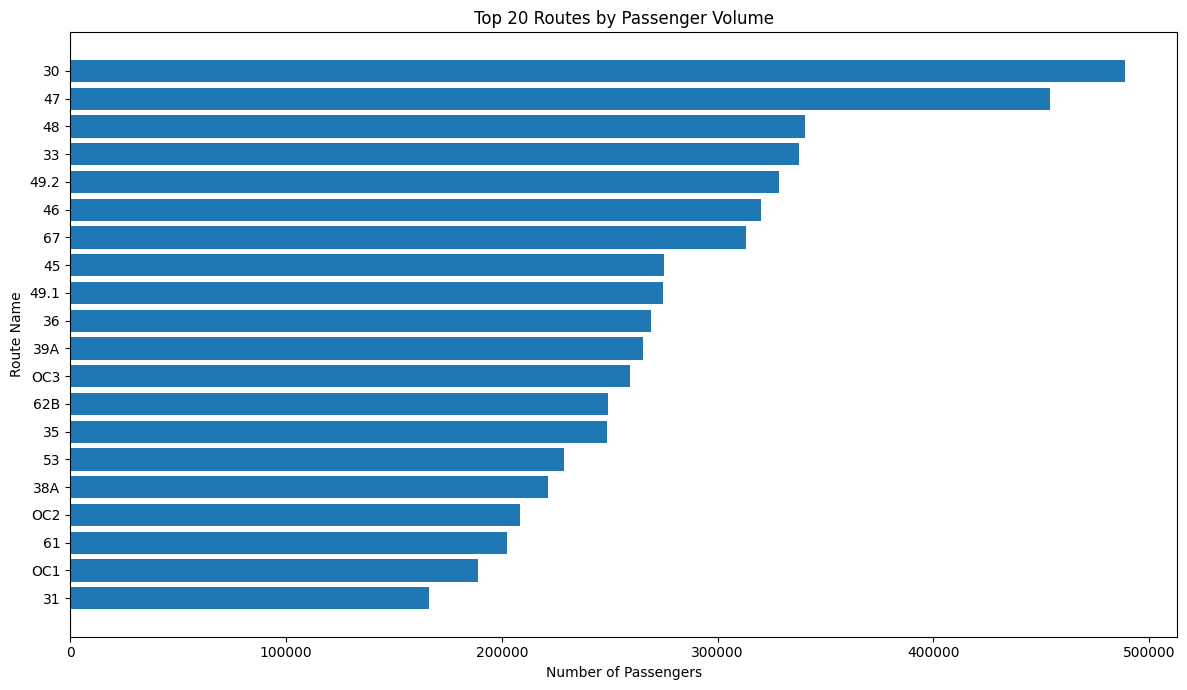

,route_name,passenger_count
0,30,488569
1,47,453994
2,48,340617
3,33,337525
4,49.2,328448
5,46,320059
6,67,313157
7,45,275151
8,49.1,274598
9,36,269325


6021

In [57]:
# 3.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"
TOP_N_ROUTES = 20

route_summary_3 = plot_passenger_demand_by_route(DATA_DIR, top_n=TOP_N_ROUTES)
display(route_summary_3)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
del TOP_N_ROUTES
gc.collect()

## 3.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [58]:
# 3.8 Cleanup

import gc

del route_summary_3
del plot_passenger_demand_by_route
gc.collect()

0

# 4. Passengers by Fare Type

## 4.1 Objective

The goal of this visualization is to measure passenger volume by fare type.

This analysis aggregates all transactions across all CSV files and counts how many passenger records are associated with each fare type.

Each row in the dataset is treated as one passenger transaction.

## 4.2 Expected Output

This section produces a chart showing:

- **x-axis:** fare type
- **y-axis:** total number of passengers
- **scope:** all CSV files found recursively inside the selected directory

This view helps compare how passenger demand is distributed across fare categories.

## 4.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [59]:
# 4.4 Code - Passenger demand by fare type

def plot_passenger_demand_by_fare_type(data_dir):
    """
    Read all CSV files recursively from a directory, aggregate passenger records by fare type,
    and plot the total number of passengers for each fare category.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - fare_type
        - passenger_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty accumulator for fare-type-level passenger counts.
    fare_counts = pd.Series(dtype="int64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the fare type column required for this analysis.
        df = pd.read_csv(file_path, usecols=["fare_type"])

        # Remove missing values.
        df = df.dropna(subset=["fare_type"])

        # Standardize values to string so categories remain consistent in aggregation.
        df["fare_type"] = df["fare_type"].astype(str).str.strip()

        # Remove empty values after cleanup.
        df = df[df["fare_type"] != ""]

        # Count passengers by fare type in the current file.
        file_fare_counts = df["fare_type"].value_counts()

        # Accumulate counts across all files.
        fare_counts = fare_counts.add(file_fare_counts, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_fare_counts
        gc.collect()

    # Convert final result to integer type and sort descending by passenger count.
    fare_counts = fare_counts.astype(int).sort_values(ascending=False)

    # Build a DataFrame for easier display and reuse.
    fare_summary = pd.DataFrame({
        "fare_type": fare_counts.index,
        "passenger_count": fare_counts.values
    })

    # Plot the result.
    plt.figure(figsize=(10, 6))
    plt.bar(fare_summary["fare_type"], fare_summary["passenger_count"])
    plt.title("Passenger Demand by Fare Type")
    plt.xlabel("Fare Type")
    plt.ylabel("Number of Passengers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return fare_summary

## 4.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with passenger totals by fare type
- a chart showing passenger demand by fare category

Found 31 CSV files.


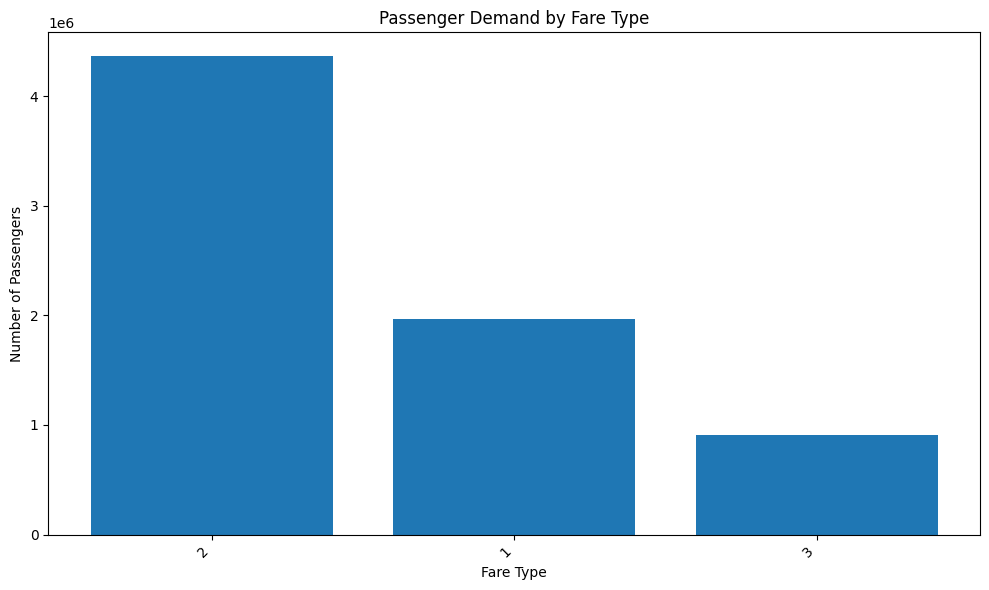

,fare_type,passenger_count
0,2,4365789
1,1,1969370
2,3,912801


2890

In [60]:
# 4.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"

fare_summary_4 = plot_passenger_demand_by_fare_type(DATA_DIR)
display(fare_summary_4)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
gc.collect()

## 4.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [61]:
# 4.8 Cleanup

import gc

del fare_summary_4
del plot_passenger_demand_by_fare_type
gc.collect()

0

# 5. Passengers by Day Period

## 5.1 Objective

The goal of this visualization is to measure passenger volume by day period.

This analysis aggregates all transactions across all CSV files and counts how many passenger records are associated with each day period category.

Each row in the dataset is treated as one passenger transaction.

## 5.2 Expected Output

This section produces a chart showing:

- **x-axis:** day period
- **y-axis:** total number of passengers
- **scope:** all CSV files found recursively inside the selected directory

This view helps compare demand across the periods of the day already defined in the dataset.

## 5.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [62]:
# 5.4 Code - Passenger demand by day period

def plot_passenger_demand_by_day_period(data_dir):
    """
    Read all CSV files recursively from a directory, aggregate passenger records by day period,
    and plot the total number of passengers for each day period category.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - day_period
        - passenger_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty accumulator for day-period-level passenger counts.
    period_counts = pd.Series(dtype="int64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the day period column required for this analysis.
        df = pd.read_csv(file_path, usecols=["day_period"])

        # Remove missing values.
        df = df.dropna(subset=["day_period"])

        # Standardize values so categories remain consistent in aggregation.
        df["day_period"] = df["day_period"].astype(str).str.strip()

        # Remove empty values after cleanup.
        df = df[df["day_period"] != ""]

        # Count passengers by day period in the current file.
        file_period_counts = df["day_period"].value_counts()

        # Accumulate counts across all files.
        period_counts = period_counts.add(file_period_counts, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_period_counts
        gc.collect()

    # Convert final result to integer type and sort descending by passenger count.
    period_counts = period_counts.astype(int).sort_values(ascending=False)

    # Build a DataFrame for easier display and reuse.
    period_summary = pd.DataFrame({
        "day_period": period_counts.index,
        "passenger_count": period_counts.values
    })

    # Plot the result.
    plt.figure(figsize=(10, 6))
    plt.bar(period_summary["day_period"], period_summary["passenger_count"])
    plt.title("Passenger Demand by Day Period")
    plt.xlabel("Day Period")
    plt.ylabel("Number of Passengers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return period_summary

## 5.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with passenger totals by day period
- a chart showing passenger demand by day period

Found 31 CSV files.


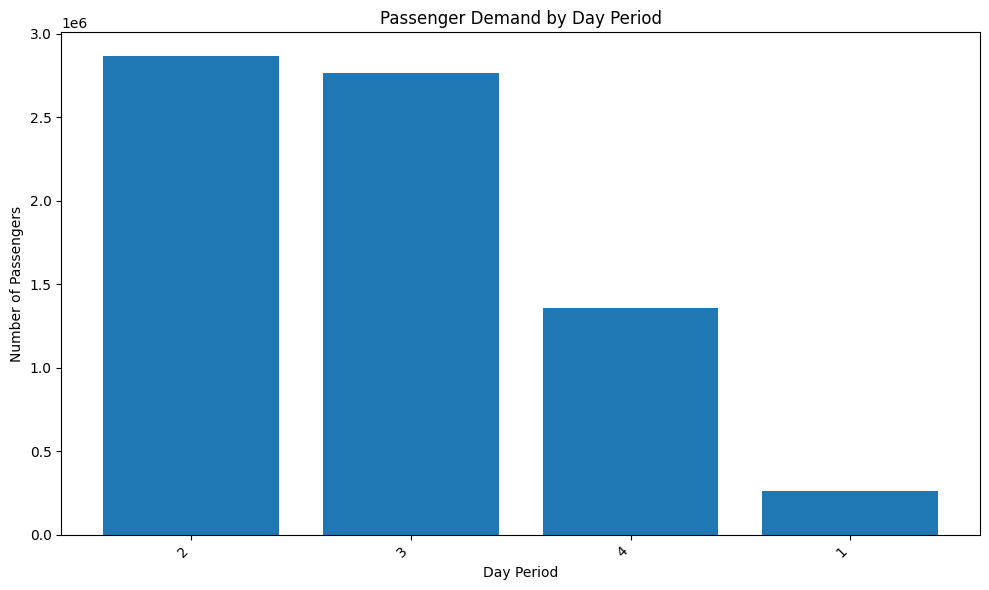

,day_period,passenger_count
0,2,2864917
1,3,2764359
2,4,1355591
3,1,263093


3309

In [63]:
# 5.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"

period_summary_5 = plot_passenger_demand_by_day_period(DATA_DIR)
display(period_summary_5)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
gc.collect()

## 5.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [64]:
# 5.8 Cleanup

import gc

del period_summary_5
del plot_passenger_demand_by_day_period
gc.collect()

0

# 6. Passengers by Day Type

## 6.1 Objective

The goal of this visualization is to measure passenger volume by day type.

This analysis aggregates all transactions across all CSV files and counts how many passenger records are associated with each day type category.

Each row in the dataset is treated as one passenger transaction.

## 6.2 Expected Output

This section produces a chart showing:

- **x-axis:** day type
- **y-axis:** total number of passengers
- **scope:** all CSV files found recursively inside the selected directory

This view helps compare passenger demand across different classes of days represented in the dataset.

## 6.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [65]:
# 6.4 Code - Passenger demand by day type

def plot_passenger_demand_by_day_type(data_dir):
    """
    Read all CSV files recursively from a directory, aggregate passenger records by day type,
    and plot the total number of passengers for each day type category.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - day_type
        - passenger_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty accumulator for day-type-level passenger counts.
    day_type_counts = pd.Series(dtype="int64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the day type column required for this analysis.
        df = pd.read_csv(file_path, usecols=["day_type"])

        # Remove missing values.
        df = df.dropna(subset=["day_type"])

        # Standardize values so categories remain consistent in aggregation.
        df["day_type"] = df["day_type"].astype(str).str.strip()

        # Remove empty values after cleanup.
        df = df[df["day_type"] != ""]

        # Count passengers by day type in the current file.
        file_day_type_counts = df["day_type"].value_counts()

        # Accumulate counts across all files.
        day_type_counts = day_type_counts.add(file_day_type_counts, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_day_type_counts
        gc.collect()

    # Convert final result to integer type and sort descending by passenger count.
    day_type_counts = day_type_counts.astype(int).sort_values(ascending=False)

    # Build a DataFrame for easier display and reuse.
    day_type_summary = pd.DataFrame({
        "day_type": day_type_counts.index,
        "passenger_count": day_type_counts.values
    })

    # Plot the result.
    plt.figure(figsize=(10, 6))
    plt.bar(day_type_summary["day_type"], day_type_summary["passenger_count"])
    plt.title("Passenger Demand by Day Type")
    plt.xlabel("Day Type")
    plt.ylabel("Number of Passengers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return day_type_summary

## 6.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with passenger totals by day type
- a chart showing passenger demand by day type

Found 31 CSV files.


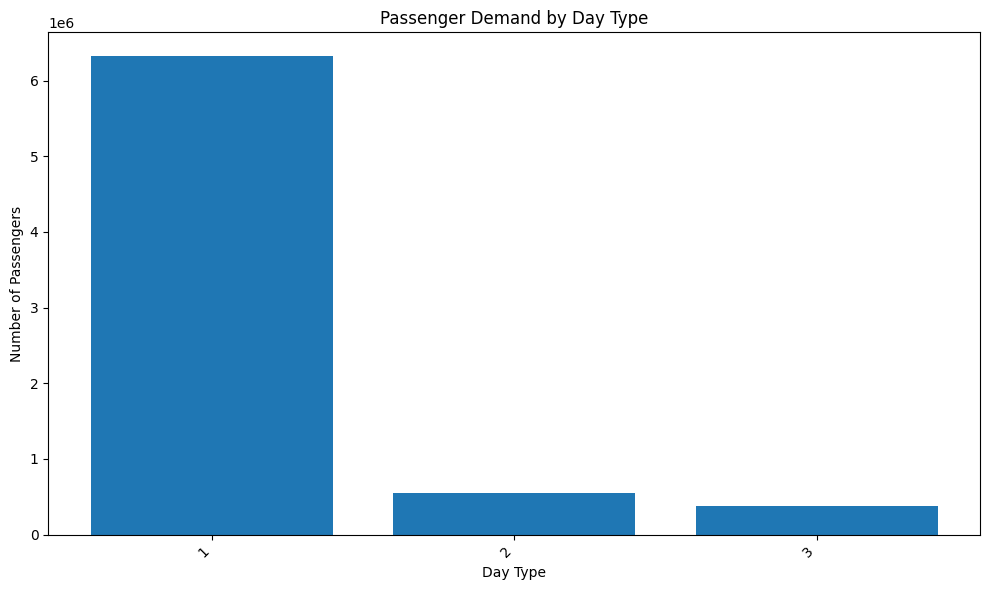

,day_type,passenger_count
0,1,6321838
1,2,550457
2,3,375665


3093

In [66]:
# 6.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"

day_type_summary_6 = plot_passenger_demand_by_day_type(DATA_DIR)
display(day_type_summary_6)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
gc.collect()

## 6.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [67]:
# 6.8 Cleanup

import gc

del day_type_summary_6
del plot_passenger_demand_by_day_type
gc.collect()

0

# 7. Revenue by Day

## 7.1 Objective

The goal of this visualization is to measure total daily revenue.

This analysis aggregates all transactions across all CSV files and sums the debited amount for each calendar day.

Each row in the dataset is treated as one transaction contributing to revenue.

## 7.2 Expected Output

This section produces a chart showing:

- **x-axis:** calendar date
- **y-axis:** total revenue
- **scope:** all CSV files found recursively inside the selected directory

This view helps identify how revenue changes over time and whether there are daily peaks or drops.

## 7.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [68]:
# 7.4 Code - Revenue by day

def plot_revenue_by_day(data_dir):
    """
    Read all CSV files recursively from a directory, aggregate debited amounts by day,
    and plot total daily revenue.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - date
        - total_revenue
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty accumulator for daily revenue.
    daily_revenue = pd.Series(dtype="float64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the columns required for this analysis.
        df = pd.read_csv(file_path, usecols=["transaction_date", "debited_amount"])

        # Convert transaction_date to datetime.
        df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

        # Convert debited_amount to numeric.
        df["debited_amount"] = pd.to_numeric(df["debited_amount"], errors="coerce")

        # Remove rows with invalid date or revenue values.
        df = df.dropna(subset=["transaction_date", "debited_amount"])

        # Extract only the calendar date from each timestamp.
        df["date"] = df["transaction_date"].dt.date

        # Sum revenue by date in the current file.
        file_daily_revenue = df.groupby("date")["debited_amount"].sum()

        # Accumulate revenue across all files.
        daily_revenue = daily_revenue.add(file_daily_revenue, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_daily_revenue
        gc.collect()

    # Sort by date.
    daily_revenue = daily_revenue.sort_index()

    # Build a DataFrame for easier display and reuse.
    revenue_summary = pd.DataFrame({
        "date": daily_revenue.index,
        "total_revenue": daily_revenue.values
    })

    # Convert date column to pandas datetime for plotting.
    revenue_summary["date"] = pd.to_datetime(revenue_summary["date"])

    # Plot the result.
    plt.figure(figsize=(14, 6))
    plt.scatter(revenue_summary["date"], revenue_summary["total_revenue"], marker="o")
    plt.title("Revenue by Day")
    plt.xlabel("Date")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return revenue_summary

## 7.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with total revenue by day
- a chart showing revenue variation across days

Found 31 CSV files.


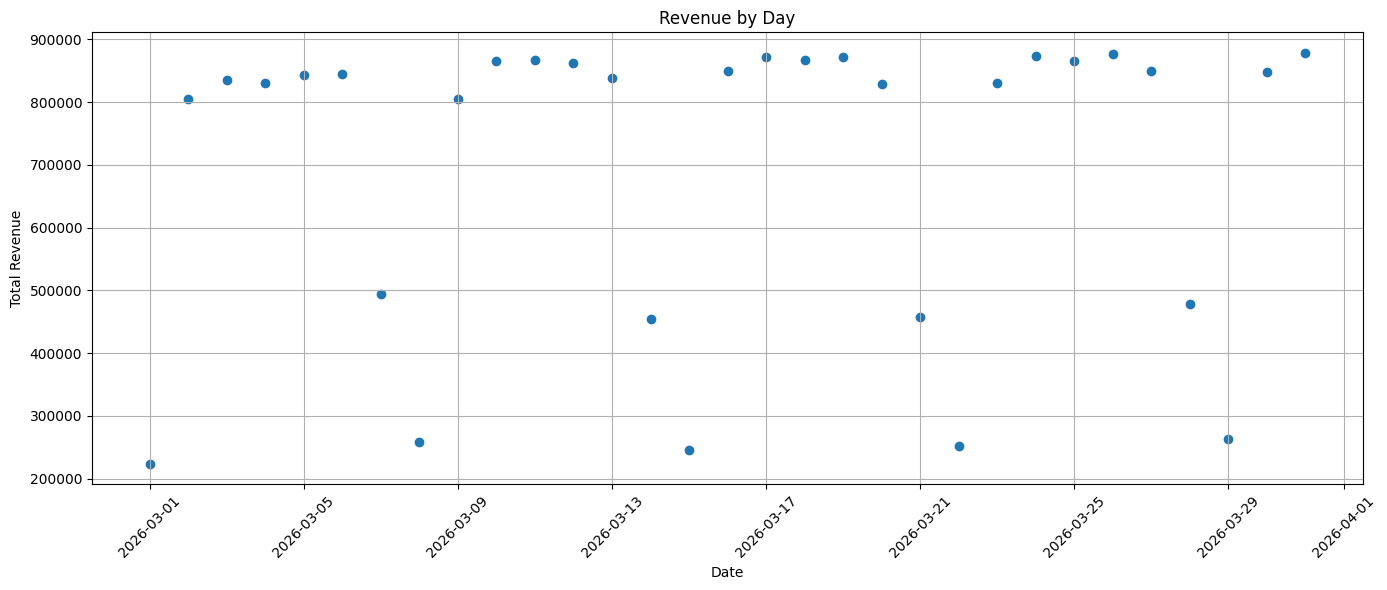

,date,total_revenue
0,2026-03-01,223649.25
1,2026-03-02,805433.95
2,2026-03-03,835842.20
3,2026-03-04,830168.25
4,2026-03-05,843958.25
5,2026-03-06,844862.95
6,2026-03-07,494277.50
7,2026-03-08,257723.30
8,2026-03-09,805017.15
9,2026-03-10,865763.85


4113

In [69]:
# 7.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"

revenue_summary_7 = plot_revenue_by_day(DATA_DIR)
display(revenue_summary_7)

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
gc.collect()

## 7.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [70]:
# 7.8 Cleanup

import gc

del revenue_summary_7
del plot_revenue_by_day
gc.collect()

0

# 8. Top 20 Most Frequent Users

## 8.1 Objective

The goal of this visualization is to identify the most frequent users in the dataset.

This analysis aggregates all transactions across all CSV files and counts how many times each user identifier appears.

The user identifier adopted in this analysis is the `id` column.

## 8.2 Expected Output

This section produces:

- a table with user transaction counts
- a chart showing the **top 20 most frequent users**
- **x-axis:** number of transactions
- **y-axis:** user identifier (`id`)

This view helps identify the users with the highest number of recorded trips or transactions in the dataset.

## 8.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [1]:
# 8.4 Code - Top 20 most frequent users by id

def plot_top_frequent_users(data_dir, top_n=100):
    """
    Read all CSV files recursively from a directory, count how many times each user id appears,
    and plot the top most frequent users.

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.
    top_n : int, default=20
        Number of top users to display in the chart.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with two columns:
        - id
        - transaction_count
    """
    # Import libraries locally so this section remains self-contained.
    from pathlib import Path
    import gc
    import pandas as pd
    import matplotlib.pyplot as plt

    # Convert input path to Path object for easier filesystem operations.
    data_dir = Path(data_dir)

    # Search recursively for all CSV files inside the directory.
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    # Create an empty accumulator for user-level transaction counts.
    user_counts = pd.Series(dtype="int64")

    # Process one file at a time to reduce memory usage.
    for file_path in csv_files:
        # Read only the id column required for this analysis.
        df = pd.read_csv(file_path, usecols=["anon_user_id"])

        # Remove missing ids.
        df = df.dropna(subset=["anon_user_id"])

        # Standardize values to string to keep aggregation consistent.
        df["anon_user_id"] = df["anon_user_id"].astype(str).str.strip()

        # Remove empty ids after cleanup.
        df = df[df["anon_user_id"] != ""]

        # Remove user_id = 0 (represents cash/no-card transactions).
        df = df[df["anon_user_id"] != "0"]

        # Count how many transactions are associated with each id in the current file.
        file_user_counts = df["anon_user_id"].value_counts()

        # Accumulate counts across all files.
        user_counts = user_counts.add(file_user_counts, fill_value=0)

        # Remove temporary objects to free memory.
        del df, file_user_counts
        gc.collect()

    # Convert final result to integer type and sort descending by transaction count.
    user_counts = user_counts.astype(int).sort_values(ascending=False)

    # Build a DataFrame for easier display and reuse.
    user_summary = pd.DataFrame({
        "id": user_counts.index,
        "transaction_count": user_counts.values
    })

    # Select the top users for visualization.
    plot_data = user_summary.head(top_n).copy()

    # Reverse order so the largest value appears at the top of the horizontal chart.
    plot_data = plot_data.iloc[::-1]

    # Plot the result.
    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    plt.barh(plot_data["id"], plot_data["transaction_count"])
    plt.title(f"Top {top_n} Most Frequent Users")
    plt.xlabel("Number of Transactions")
    plt.ylabel("User ID")
    plt.tight_layout()
    plt.show()

    return user_summary

## 8.5 Execution

In the next cell, define the directory containing the processed CSV files and run the function.

The result will be:
- a table with transaction counts by user id
- a chart showing the top 20 most frequent users

Found 31 CSV files.


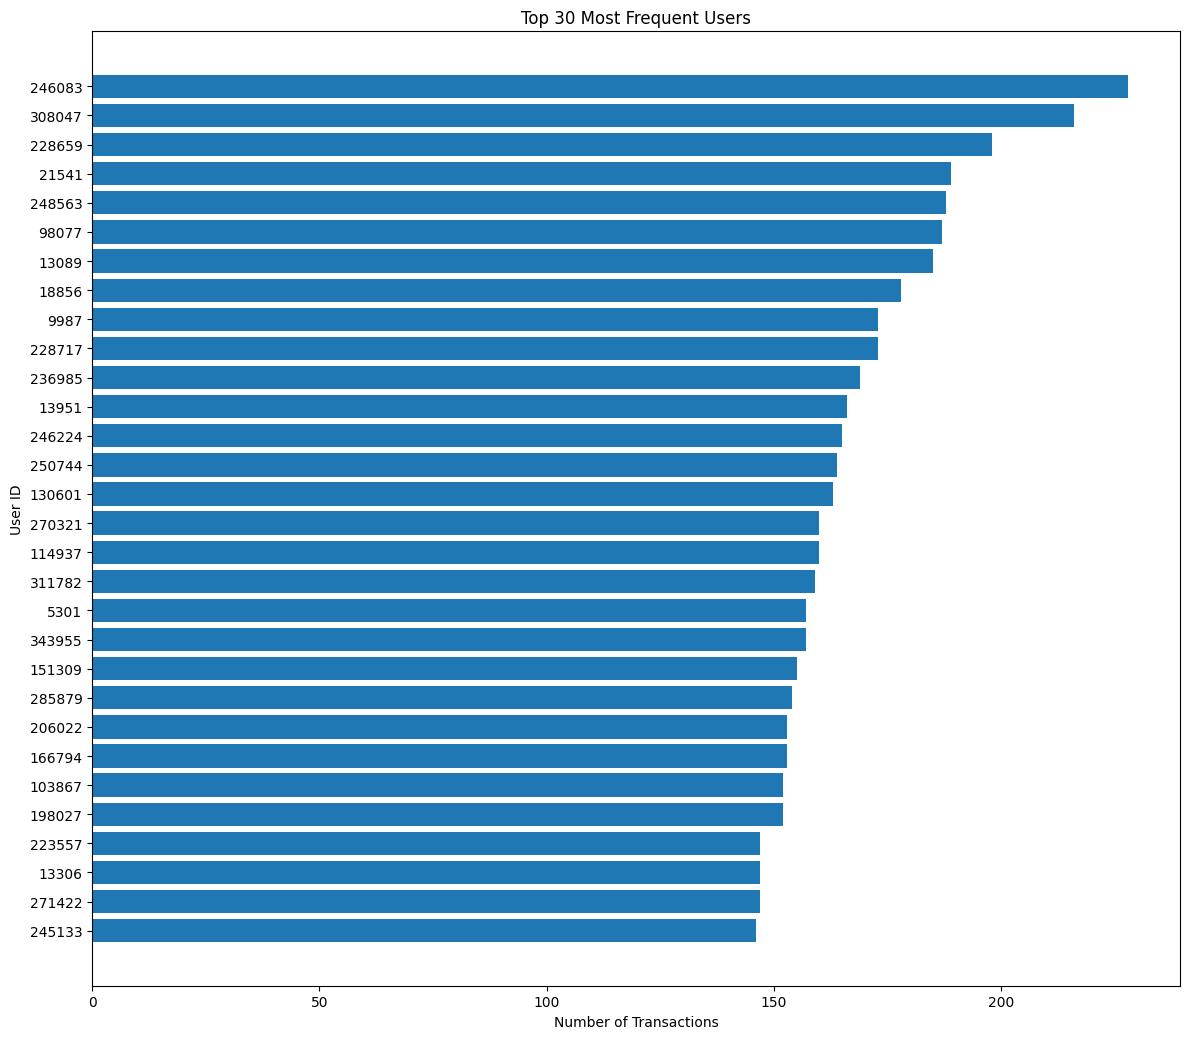

,id,transaction_count
0,246083,228
1,308047,216
2,228659,198
3,21541,189
4,248563,188
5,98077,187
6,13089,185
7,18856,178
8,9987,173
9,228717,173


7723

In [4]:
# 8.6 Run the analysis

import gc

DATA_DIR = "/data/vm/anonymyzed_seq/"
TOP_N_USERS = 30

user_summary_8 = plot_top_frequent_users(DATA_DIR, top_n=TOP_N_USERS)
display(user_summary_8.head(TOP_N_USERS))

# Clean up execution-level variables that are no longer necessary.
del DATA_DIR
del TOP_N_USERS
gc.collect()

In [73]:
TOP_N_USERS = 20
display(user_summary_8.iloc[1:].head(TOP_N_USERS))

,id,transaction_count
1,308047,216
2,228659,198
3,21541,189
4,248563,188
5,98077,187
6,13089,185
7,18856,178
8,9987,173
9,228717,173
10,236985,169


In [74]:
def filter_by_chipcartao(df, chip_cartao):
    """
    Filter and print all occurrences of a specific CHipcartao.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing transactions
    chip_cartao : int or str
        CHipcartao value to filter
    
    Returns:
    --------
    pandas.DataFrame
        Filtered DataFrame with matching CHipcartao
    """
    #filtered = df[df['ChipCartao'] == chip_cartao]
    filtered = df[df['anon_user_id'] == chip_cartao]
    print(f"\n{'='*80}")
    print(f"🔍 OCORRÊNCIAS DO CHIP CARTÃO: {chip_cartao}")
    print(f"{'='*80}")
    print(f"Total de ocorrências: {len(filtered)}\n")
    #print(filtered.to_string(index=False))
    
    return filtered



In [77]:
# Uso:
resultado = filter_by_chipcartao(df_data, 308047)
resultado


🔍 OCORRÊNCIAS DO CHIP CARTÃO: 308047
Total de ocorrências: 216



,transaction_date,fare_type,vehicle_number,company_number,route_detail_id,integration_flag,card_type,debited_amount,view_type,route_name,day_type,day_period,anon_user_id
837,2026-03-01 02:23:28-03:00,1,22013,56,2726,1,4,0.0,SAPE - CENTRO,36,3,1,308047
1770,2026-03-01 02:46:49-03:00,1,2040,56,2713,1,4,0.0,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,308047
22518,2026-03-01 07:17:31-03:00,1,2024,56,2717,1,4,0.0,ITAIPU - CENTRO (VIA ENGENHO DO MATO),38A,3,2,308047
23471,2026-03-01 07:29:44-03:00,1,2047,56,2713,1,4,0.0,VÁRZEA DAS MOÇAS - CENTRO,46,3,2,308047
28457,2026-03-01 08:44:47-03:00,1,2112,56,2721,1,4,0.0,VARZEA DAS MOÇAS X PIRATININGA - (VIA CAFUBÁ),55A,3,2,308047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7051485,2026-03-31 06:55:40-03:00,1,2156,56,2723,1,4,0.0,ITAIPU X CENTRO - (VIA PRAIA ICARAÍ),OC3,1,2,308047
7056577,2026-03-31 07:17:34-03:00,1,2054,56,2864,1,4,0.0,RJ 106 X CENTRO,46P,1,2,308047
7066074,2026-03-31 07:59:58-03:00,1,2116,56,2721,1,4,0.0,VARZEA DAS MOÇAS X PIRATININGA - (VIA CAFUBÁ),55A,1,2,308047
7080023,2026-03-31 08:54:15-03:00,1,2117,56,2713,1,4,0.0,VÁRZEA DAS MOÇAS - CENTRO,46,1,2,308047


# 9. Trip Distribution per Passenger

## 9.1 Objective

The goal of this visualization is to understand how trips are distributed across passengers in the dataset.

This analysis aggregates all transactions across all CSV files, counts how many trips each user identifier performed, and plots the resulting frequency distribution as a histogram.

The user identifier adopted in this analysis is the `anon_user_id` column.
Cash transactions (`anon_user_id = 0`) are excluded from this analysis.

## 9.2 Expected Output

This section produces:

- a histogram showing the **distribution of trips per passenger**
- **x-axis:** number of trips per user
- **y-axis:** number of users with that trip count
- vertical reference lines for the **mean** and **median** trip count

This view helps identify whether trip frequency follows a uniform, normal, or skewed distribution — and detect the presence of heavy or occasional users.

## 9.3 Notes

This section is fully independent from the others:
- it defines its own imports
- it defines its own function
- it does not depend on previous notebook cells

The optional `max_trips` parameter can be used to clip the x-axis and improve
readability when a small number of heavy users would otherwise compress the bulk
of the distribution into the leftmost bins.

At the end of the execution, temporary variables and objects are deleted to help reduce memory usage.

In [7]:
from pathlib import Path
import gc
import pandas as pd
import matplotlib.pyplot as plt

def plot_trips_per_user_histogram(data_dir, bins=50, max_trips=None):
    """
    Read all CSV files recursively from a directory and plot a histogram
    of trip counts per user, excluding user_id = 0 (cash transactions).

    Parameters
    ----------
    data_dir : str or pathlib.Path
        Root directory containing the processed CSV files.
    bins : int, default=50
        Number of histogram bins.
    max_trips : int or None, default=None
        If set, clips the x-axis to this value to improve readability
        when a few heavy users would otherwise compress the distribution.

    Returns
    -------
    pandas.Series
        Series indexed by anon_user_id with total trip counts.
    """


    data_dir = Path(data_dir)
    csv_files = sorted(data_dir.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files were found in: {data_dir}")

    print(f"Found {len(csv_files)} CSV files.")

    user_counts = pd.Series(dtype="int64")

    for file_path in csv_files:
        df = pd.read_csv(file_path, usecols=["anon_user_id"])
        df = df.dropna(subset=["anon_user_id"])
        df["anon_user_id"] = df["anon_user_id"].astype(str).str.strip()
        df = df[df["anon_user_id"] != ""]
        df = df[df["anon_user_id"] != "0"]

        file_user_counts = df["anon_user_id"].value_counts()
        user_counts = user_counts.add(file_user_counts, fill_value=0)

        del df, file_user_counts
        gc.collect()

    user_counts = user_counts.astype(int)

    # Optionally clip heavy users to improve histogram readability.
    plot_data = user_counts.clip(upper=max_trips) if max_trips else user_counts

    # Summary stats for the plot annotation.
    median_val = int(plot_data.median())
    mean_val   = int(plot_data.mean())

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.hist(plot_data, bins=bins, edgecolor="white", linewidth=0.4)

    # Vertical reference lines for median and mean.
    ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5,
               label=f"Median: {median_val}")
    ax.axvline(mean_val,   color="red",    linestyle="--", linewidth=1.5,
               label=f"Mean: {mean_val}")

    ax.set_title("Distribution of Trips per Passenger")
    ax.set_xlabel("Number of Trips")
    ax.set_ylabel("Number of Users")
    ax.legend()

    title_suffix = f" (clipped at {max_trips})" if max_trips else ""
    ax.set_title(f"Distribution of Trips per Passenger{title_suffix}")

    plt.tight_layout()
    plt.show()

    return user_counts

Found 31 CSV files.


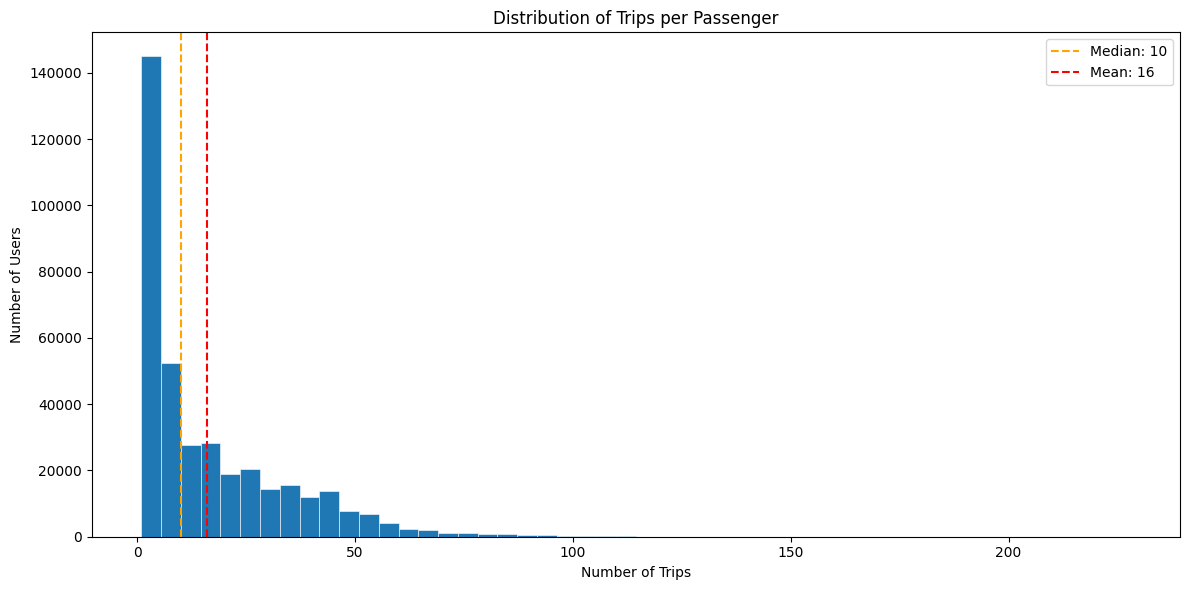

Found 31 CSV files.


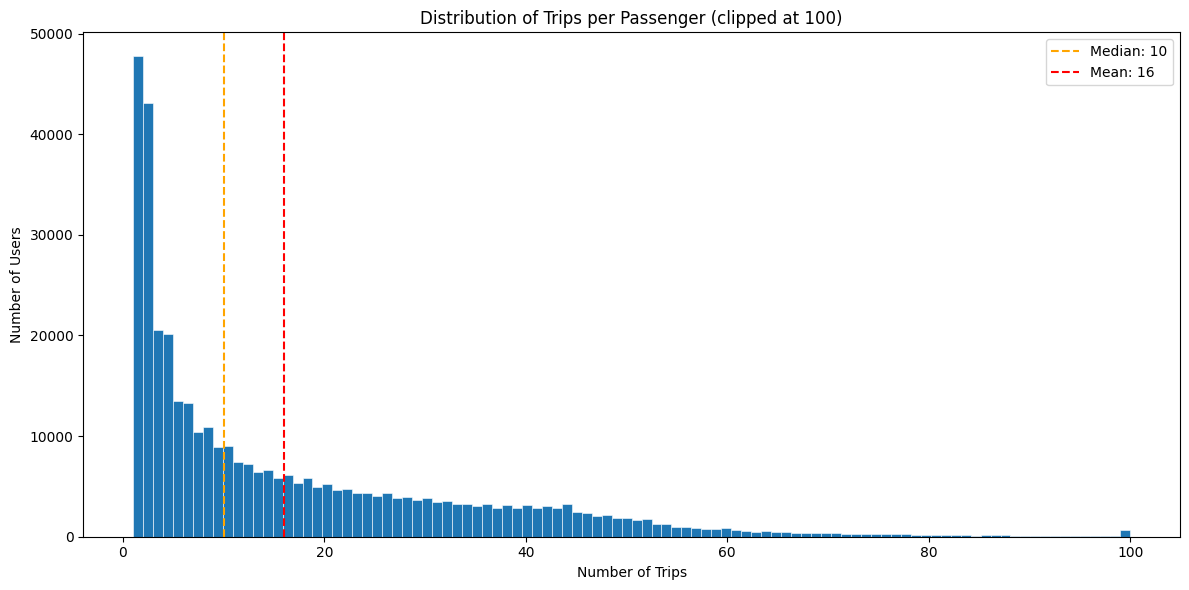

In [8]:
DATA_DIR = "/data/vm/anonymyzed_seq/"

# Full distribution
counts = plot_trips_per_user_histogram(data_dir=DATA_DIR)

# Zoom into users with up to 100 trips (ignores outliers visually)
counts = plot_trips_per_user_histogram(data_dir=DATA_DIR, max_trips=100, bins=100)

## 8.7 Memory Cleanup

After the visualization is complete, the objects created specifically for this section can be removed from memory.

This is useful when the notebook will later run additional analyses on large datasets.

In [9]:
# 8.8 Cleanup

import gc

del user_summary_8
del plot_top_frequent_users
gc.collect()

10112